In [3]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import math
import wandb
from dotenv import load_dotenv

# Load environment variables from .env file
# The .env file should contain: WANDB_API_KEY, WANDB_PROJECT, HF_TOKEN
env_path = Path("../.env")
if env_path.exists():
    load_dotenv(env_path)
    print(f"Loaded environment variables from {env_path}")
else:
    print(f"Warning: {env_path} not found. Set WANDB_API_KEY and HF_TOKEN manually.")


# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# os.environ["HF_TOKEN"]= user_secrets.get_secret("hf_api")
# os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")


# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

Loaded environment variables from ../.env
PyTorch version: 2.7.0
timm version: 1.0.24


In [4]:
# Device configuration
# MPS (Metal Performance Shaders) provides GPU acceleration on Apple Silicon (if you want to run this notebook locally on your MacBook)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

Using CPU
Device: cpu


In [29]:
# Configuration
config = {
    # Paths
    "data_dir": Path("../data"),
    "checkpoint_dir": Path("checkpoints"),
    
    # Model
    "model_name": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,

    "megadescriptor_dim": 1536,

    "embedding_dim": 256,
    "hidden_dim": 512,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

# Create checkpoint directory
config["checkpoint_dir"].mkdir(exist_ok=True)

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  data_dir: ../data
  checkpoint_dir: checkpoints
  model_name: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  megadescriptor_dim: 1536
  embedding_dim: 256
  hidden_dim: 512
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 50
  patience: 10
  val_split: 0.2
  seed: 42


In [6]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
wandb.login(key=os.environ["WANDB_API_KEY"])

wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-baseline"),
    config={
        # Model architecture
        "megadescriptor_model": config["megadescriptor_model"],
        "embedding_dim": config["embedding_dim"],
        "hidden_dim": config["hidden_dim"],
        "dropout": config["dropout"],
        
        # ArcFace hyperparameters (critical for performance)
        "arcface_margin": config["arcface_margin"],
        "arcface_scale": config["arcface_scale"],
        
        # Training hyperparameters
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "num_epochs": config["num_epochs"],
        "patience": config["patience"],
        "val_split": config["val_split"],
        "seed": config["seed"],
    },
    name="megadescriptor-arcface-local",
)

print("W&B initialized. Key hyperparameters tracked:")
print(f"  Project: {os.getenv('WANDB_PROJECT', 'jaguar-reid-baseline')}")
print(f"  ArcFace margin: {config['arcface_margin']} ({config['arcface_margin'] * 180 / 3.14159:.1f}°)")
print(f"  ArcFace scale: {config['arcface_scale']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Dropout: {config['dropout']}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/matthias/.netrc
wandb: Currently logged in as: matthiascr (matthiascr-hpi-team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B initialized. Key hyperparameters tracked:
  Project: jaguar-reid-baseline
  ArcFace margin: 0.5 (28.6°)
  ArcFace scale: 64.0
  Embedding dim: 256
  Dropout: 0.3


In [7]:
# Load training data
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

# Analyze identity distribution
identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min images per identity: {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max images per identity: {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean images per identity: {identity_counts.mean():.1f}")

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min images per identity: 13 (Ipepo)
  Max images per identity: 183 (Marcela)
  Mean images per identity: 61.1


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


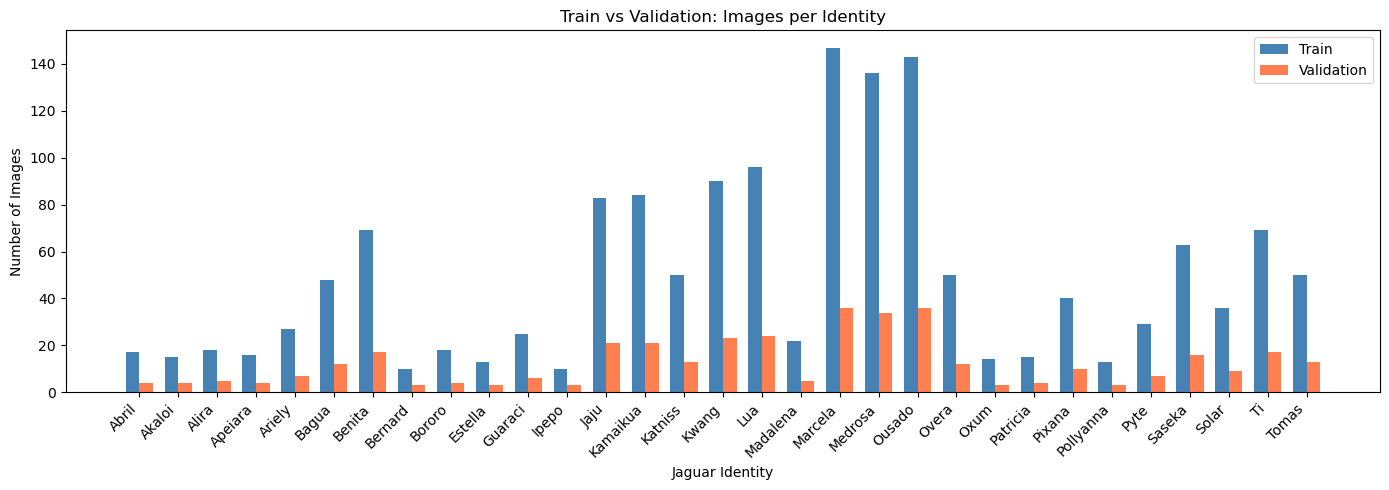


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [8]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

In [22]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)

print(f"Model loaded successfully")
print(f"  Parameters: {sum(p.numel() for p in megadescriptor.parameters()):,}")

# Get the embedding dimension from the model
with torch.no_grad():
    dummy_input = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

Loading MegaDescriptor-L-384 model...
Model loaded successfully
  Parameters: 195,198,516
  Embedding dimension: 1536


In [ ]:
# Define preprocessing pipeline
# MegaDescriptor expects 384x384 images normalized with ImageNet statistics
preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print("Preprocessing pipeline configured:")
print(f"  Resize to: {config['input_size']}x{config['input_size']}")
print(f"  Normalization: ImageNet statistics")

## Dataset

In [ ]:
class JaguarDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.is_test = is_test
        if not is_test:
            unique_ids = sorted(df["ground_truth"].unique())
            self.label_map = {name: i for i, name in enumerate(unique_ids)}
            self.df["label"] = self.df["ground_truth"].map(self.label_map)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row["filename"]
        img_path = self.img_dir / img_name
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            img = Image.new("RGB", (config['input_size'], config['input_size']))

        if self.transform:
            img = self.transform(img)
        if self.is_test:
            return img, img_name
        return img, torch.tensor(row["label"], dtype=torch.long)


In [11]:
train_transform = transforms.Compose(
    [
        transforms.Resize((config['input_size'], config['input_size'])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.481, 0.457, 0.408], [0.268, 0.261, 0.275]),
        transforms.RandomErasing(p=0.25),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((config['input_size'], config['input_size'])),
        transforms.ToTensor(),
        transforms.Normalize([0.481, 0.457, 0.408], [0.268, 0.261, 0.275]),
    ]
)

In [12]:
train_loader = DataLoader(
    JaguarDataset(train_data, '../data/train/train', train_transform),
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=False,
)

val_loader = DataLoader(
    JaguarDataset(val_data, '../data/train/train', train_transform),
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=False,
)

In [17]:
img, label = next(iter(train_loader))


## Model

In [20]:
class EmbeddingProjection(nn.Module):
    """
    Projects MegaDescriptor embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.
    
    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # Compute sin(theta) from cos(theta)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        
        # Compute cos(theta + m) using angle addition formula
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        
        # Apply threshold to handle theta + m >= pi
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot encode labels
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        # Apply margin only to ground truth class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # Scale logits
        output = output * self.scale
        
        return output


print("EmbeddingProjection and ArcFaceLayer defined")



EmbeddingProjection and ArcFaceLayer defined


In [30]:
class ArcFaceModel(nn.Module):
    """Complete model: Embedding Projection + ArcFace."""
    
    def __init__(self, input_dim, num_classes, embedding_dim=256, hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()

        self.backbone = timm.create_model(
            config['model_name'], pretrained=True, num_classes=0
        )
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim, 
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout
        )
        self.arcface = ArcFaceLayer(
            embedding_dim=embedding_dim, 
            num_classes=num_classes,
            margin=margin, 
            scale=scale
        )
    
    def forward(self, x, labels):
        """Forward pass for training (requires labels for ArcFace)."""
        features = self.backbone(x)
        embeddings = self.embedding_net(features)
        logits = self.arcface(embeddings, labels)
        return logits, embeddings
    
    def get_embeddings(self, x):
        """Get normalized embeddings for inference."""
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)


# Create model
model = ArcFaceModel(
    input_dim=config['megadescriptor_dim'],
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

print(f"ArcFace Model:")
print(f"  Input dim: {config['megadescriptor_dim']}")
print(f"  Hidden dim: {config['hidden_dim']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Dropout: {config['dropout']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")

print(f"  ArcFace scale: {config['arcface_scale']}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

ArcFace Model:
  Input dim: 1536
  Hidden dim: 512
  Embedding dim: 256
  Dropout: 0.3
  Num classes: 31
  ArcFace margin: 0.5
  ArcFace scale: 64.0
  Total parameters: 196,126,260


In [31]:
batch, label = next(iter(train_loader))

In [ ]:
output = model(batch, label)